In [2]:
#!pip install matplotlib

Shapiro's test for Tiktok:(np.float64(0.9434562921665588), np.float64(0.010036941584972734))
Levene's test:(np.float64(47.65306300882635), np.float64(4.0481699623176426e-17))
t-statistic for Tiktok vs Facebook: -1.401691707989318
P-value: 0.1665257366657768
t-statistic for Tiktok vs Population: -0.8522997901883106
P-value: 0.39767816988562776
Wilcoxon-statistic for Tiktok vs Facebook: 681.0
P-value: 0.24766979550311485
Wilcoxon-statistic for Tiktok vs Population: 735.0
P-value: 0.46723420121144066


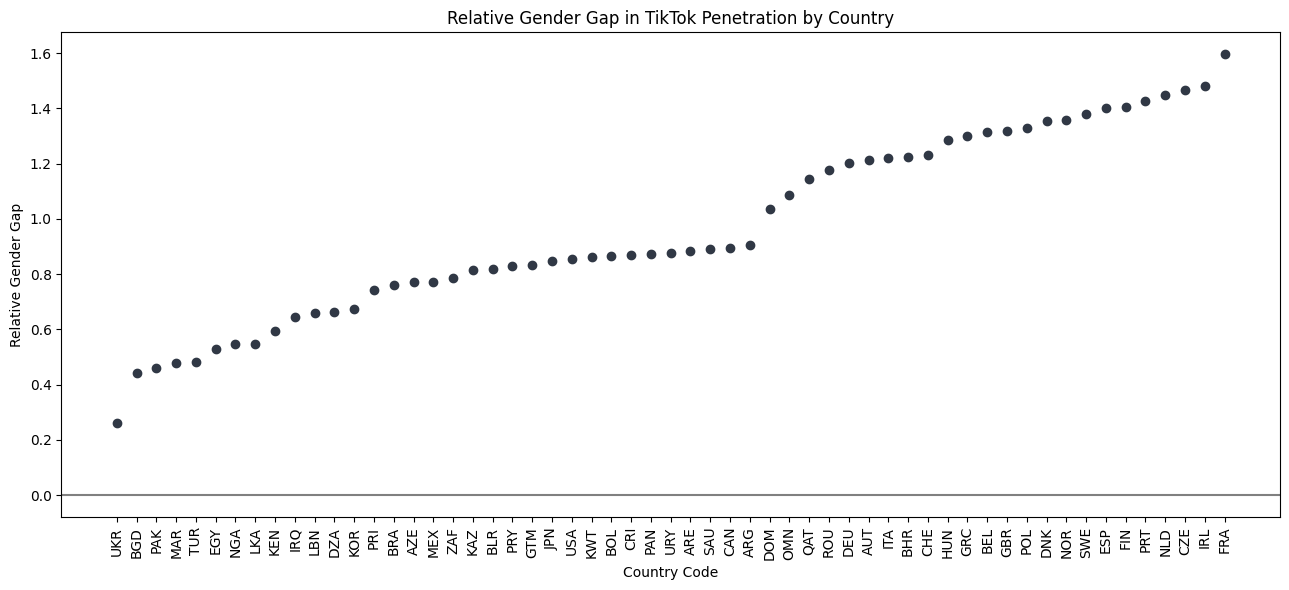

In [27]:
#### Statistical Tests and Analyses
import math
import numpy as np
from scipy.stats import shapiro, ttest_rel, levene, wilcoxon
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

TT = Path("outputs/gap_by_country.csv")
FB = Path("merged_fb.csv")

tt_df = pd.read_csv(TT, encoding="utf-8-sig")
fb_df = pd.read_csv(FB, encoding="utf-8-sig")

#perform Shapiro-Wilk test for normality, H0=normal distribution, If the p-value of the test > α = .05, then the data is assumed to be normally distributed
tiktok = tt_df["tt_fm"]
stat, p = shapiro(tiktok)
print(f"Shapiro's test for Tiktok:{stat, p}")

#test homogeneity of variance, H0=euqal variance, homoscedastic, if we get a p-value > 0.05 we can assume that our data is heteroscedastic (which is what we want)
facebook = fb_df["fb_fm"]
population = tt_df["pop_fm"]

stat, p = levene(tiktok, facebook, population)

print(f"Levene's test:{stat, p}")

# Perform two-sample paired t-test if assumptions are met

t_statistic_ft, p_value_ft = ttest_rel(tiktok, facebook)
t_statistic_pt, p_value_pt = ttest_rel(tiktok, population)

# Output the results
print(f"t-statistic for Tiktok vs Facebook: {t_statistic_ft}")
print(f"P-value: {p_value_ft}")

print(f"t-statistic for Tiktok vs Population: {t_statistic_pt}")
print(f"P-value: {p_value_pt}")

# Perform Wilcoxon test if assumptions are not met

t_statistic_ft, p_value_ft = wilcoxon(tiktok, facebook)
t_statistic_pt, p_value_pt = wilcoxon(tiktok, population)

# Output the results
print(f"Wilcoxon-statistic for Tiktok vs Facebook: {t_statistic_ft}")
print(f"P-value: {p_value_ft}")

print(f"Wilcoxon-statistic for Tiktok vs Population: {t_statistic_pt}")
print(f"P-value: {p_value_pt}")


### Create Scatterplot of Tiktok Relative Gender Gap
tt_df_sorted = tt_df.sort_values("relative_gap", ascending=True)
plt.figure(figsize=(13, 6))
plt.scatter(tt_df_sorted["country_code"], tt_df_sorted["relative_gap"],color='#303845')

# Add horizontal line at 0 to show baseline
plt.axhline(0, color='gray')

# Labels and title
plt.xticks(rotation=90)
plt.xlabel("Country Code")
plt.ylabel("Relative Gender Gap")
plt.title("Relative Gender Gap in TikTok Penetration by Country")
plt.tight_layout()
plt.grid(False)
plt.show()

Shapiro: reject H0 -> tiktok data not normally distributed <br>
Levene: reject H0 -> different variances, heteroscedastic <br>
Wilcoxon: both p-values are >.05, fail to reject H0, Tiktok values are not statistically different from the facebook or population values <br>
The results showed no statistically significant difference between TikTok and Facebook gender ratios (Wilcoxon statistic = 681.0, p > 0.05), nor between TikTok and the population gender ratios (Wilcoxon statistic = 735.0, p >0.05).


In [ ]:
# compare audience estimates to population
# descriptive table summary:
######## N countries, min, max, mean, sd
#Gender + Overall
# TT Pen
# TT Gap
# Pop Gap
# Rel Gap

tbl = pd.read_csv("outputs/summary_table.csv")
tbl = tbl.round({
    'count': 0,
    'mean': 2,
    'std': 2,
    'min': 2,
    '25%': 2,
    '50%': 2,
    '75%': 2,
    'max': 2
})
formatters = {
    'count': '{:,.0f}'.format,
    'mean': '{:,.2f}'.format,
    'std': '{:,.2f}'.format,
    'min': '{:,.2f}'.format,
    '25%': '{:,.2f}'.format,
    '50%': '{:,.2f}'.format,
    '75%': '{:,.2f}'.format,
    'max': '{:,.2f}'.format
}
tbl = tbl.reset_index().rename(columns={'index': 'Variable'})
tbl = tbl[['Variable', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# Apply style with formatting
styled = tbl.style.format(formatters)\
    .set_properties(**{
        'text-align': 'right',
        'font-family': 'Arial',
        'border': '1px solid black'
    })\
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'right'), ('font-weight', 'bold')]
    }])\
    .hide(axis='index')

# Export to HTML (for Word or web embedding)
styled.to_html("outputs/publication_ready_table.html")

# Optional: Show in Jupyter (if in notebook)
styled

KeyError: "['Variable'] not in index"